# Scanner study — Paladin-derived cross-sectional templates

**Concluded NEGATIVE 2026-08-23** — see `findings.md` for the full write-up.

171-symbol Binance futures universe, 15m, 2024-01→2026-08. IS/OOS split at 2025-09. 18bp round-trip taker costs, next-bar-open fills, conservative stop-first bar ambiguity.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 200)
v1 = pd.read_csv('results/variant_summary.csv')
v2 = pd.read_csv('results/variant_summary_v2.csv')
print(f"v1: {v1.variant.nunique()} variants   v2: {v2.variant.nunique()} variants")


v1: 28 variants   v2: 24 variants


## Variant tables

In [2]:
cols = ['variant','split','n','net_exp_r','gross_exp_r','wr_pct','total_r','max_dd_r','trades_per_day','med_cost_r']
print('=== v1 A (sweep-fade short): best by OOS net expectancy ===')
a = v1[v1.variant.str.startswith('A_') & (v1.split=='OOS')].sort_values('net_exp_r', ascending=False)
display(a[cols].head(8).round(3))
print('=== v1 B (RS-dump long): all decisively negative ===')
display(v1[v1.variant.str.startswith('B_')][cols].round(3))
print('=== v2 A2 (pre-registered refinement): gross edge did NOT concentrate ===')
display(v2[v2.split=='OOS'].sort_values('net_exp_r', ascending=False)[cols].head(8).round(3))


=== v1 A (sweep-fade short): best by OOS net expectancy ===


,variant,split,n,net_exp_r,gross_exp_r,wr_pct,total_r,max_dd_r,trades_per_day,med_cost_r
22,A_sweepfade_1_2.5_1.5_skip_up30d,OOS,14255,0.012,0.073,45.844,167.368,-463.632,40.382,0.051
16,A_sweepfade_1_2.5_1.0_skip_up30d,OOS,14255,0.008,0.068,53.665,108.622,-366.509,40.382,0.051
19,A_sweepfade_1_2.5_1.5_None,OOS,15440,0.002,0.063,45.389,25.307,-643.748,43.493,0.051
13,A_sweepfade_1_2.5_1.0_None,OOS,15440,-0.001,0.060,53.219,-22.567,-549.277,43.493,0.051
10,A_sweepfade_1_1.5_1.5_skip_up30d,OOS,14255,-0.007,0.095,44.104,-97.214,-646.042,40.382,0.085
46,A_sweepfade_3_2.5_1.5_skip_up30d,OOS,6813,-0.010,0.050,44.312,-66.849,-240.802,19.300,0.051
40,A_sweepfade_3_2.5_1.0_skip_up30d,OOS,6813,-0.018,0.042,52.062,-121.067,-224.449,19.300,0.051
7,A_sweepfade_1_1.5_1.5_None,OOS,15440,-0.021,0.081,43.549,-330.167,-883.224,43.493,0.086


=== v1 B (RS-dump long): all decisively negative ===


,variant,split,n,net_exp_r,gross_exp_r,wr_pct,total_r,max_dd_r,trades_per_day,med_cost_r
72,B_rsdump_0.01_0.01_1.5_1.0_None,IS,12117,-0.345,-0.264,36.717,-4182.705,-4202.384,21.036,0.070
73,B_rsdump_0.01_0.01_1.5_1.0_None,OOS,9367,-0.305,-0.215,39.148,-2854.210,-2879.527,26.386,0.074
74,B_rsdump_0.01_0.01_1.5_1.0_None,ALL,21484,-0.328,-0.243,37.777,-7036.915,-7057.560,23.027,0.071
75,B_rsdump_0.01_0.01_1.5_1.5_None,IS,12117,-0.330,-0.249,30.148,-4001.109,-4054.284,21.036,0.070
76,B_rsdump_0.01_0.01_1.5_1.5_None,OOS,9367,-0.312,-0.222,31.237,-2924.576,-3019.099,26.386,0.074
77,B_rsdump_0.01_0.01_1.5_1.5_None,ALL,21484,-0.322,-0.237,30.623,-6925.685,-6980.326,23.027,0.071
78,B_rsdump_0.01_0.01_2.5_1.0_None,IS,12117,-0.199,-0.150,42.090,-2407.097,-2522.045,21.036,0.042
79,B_rsdump_0.01_0.01_2.5_1.0_None,OOS,9367,-0.210,-0.156,41.550,-1968.811,-2115.461,26.386,0.044
80,B_rsdump_0.01_0.01_2.5_1.0_None,ALL,21484,-0.204,-0.153,41.854,-4375.908,-4491.835,23.027,0.043
81,B_rsdump_0.01_0.01_2.5_1.5_None,IS,12117,-0.190,-0.141,36.073,-2303.355,-2492.252,21.036,0.042


=== v2 A2 (pre-registered refinement): gross edge did NOT concentrate ===


,variant,split,n,net_exp_r,gross_exp_r,wr_pct,total_r,max_dd_r,trades_per_day,med_cost_r
22,A2_1_2.5_1.0_skip_up30d,OOS,1384,-0.042,-0.001,49.783,-58.137,-62.939,3.932,0.039
28,A2_1_2.5_1.5_skip_up30d,OOS,1384,-0.044,-0.003,42.991,-61.245,-78.774,3.932,0.039
19,A2_1_2.5_1.0_None,OOS,1520,-0.049,-0.009,49.276,-75.008,-81.638,4.294,0.039
34,A2_1_2.5_2.0_skip_up30d,OOS,1384,-0.050,-0.009,40.896,-69.401,-81.776,3.932,0.039
25,A2_1_2.5_1.5_None,OOS,1520,-0.053,-0.012,42.368,-80.564,-86.599,4.294,0.039
31,A2_1_2.5_2.0_None,OOS,1520,-0.055,-0.015,40.329,-84.224,-94.391,4.294,0.039
13,A2_1_1.5_2.0_None,OOS,1520,-0.056,0.012,35.197,-84.732,-93.244,4.294,0.065
16,A2_1_1.5_2.0_skip_up30d,OOS,1384,-0.057,0.012,35.332,-78.501,-95.799,3.932,0.066


## The story in one chart: gross vs net

,n,gross,net
year,,,
2024,7551,0.026,-0.032
2025,13515,0.056,-0.001
2026,8606,0.036,-0.026


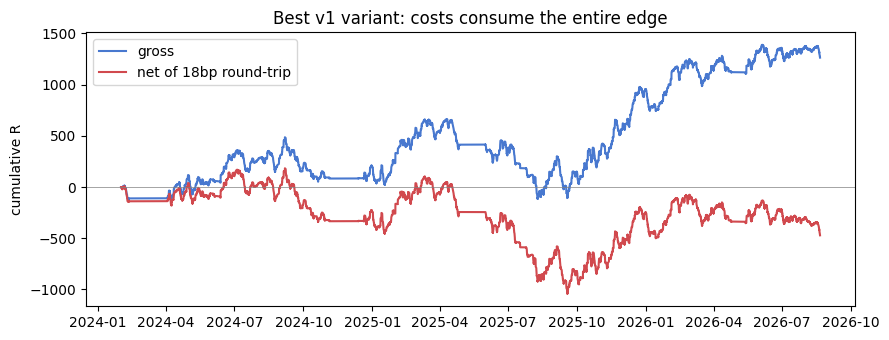

In [3]:
t = pd.read_csv('results/trades_A_sweepfade_1_2.5_1.5_skip_up30d.csv', parse_dates=['time']).sort_values('time')
fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(t.time, t.gross_r.cumsum(), label='gross', color='#4878cf')
ax.plot(t.time, t.net_r.cumsum(), label='net of 18bp round-trip', color='#d1494e')
ax.axhline(0, color='gray', lw=.5); ax.legend()
ax.set_ylabel('cumulative R'); ax.set_title('Best v1 variant: costs consume the entire edge')
plt.tight_layout()
byyear = t.assign(year=t.time.dt.year).groupby('year').agg(
    n=('net_r','size'), gross=('gross_r','mean'), net=('net_r','mean')).round(3)
display(byyear)
